# 04 : Évaluation clinique et interprétabilité

Le Notebook 03 a sélectionné le meilleur modèle sur le jeu de validation et l'a sauvegardé dans `models/best_model.pt`. Ce notebook charge ce modèle et l'évalue **une seule fois, sur le jeu de test mis de côté, qu'il n'a jamais vu pendant l'entraînement ni pendant la sélection**.

Le résultat est présenté dans les termes qui comptent pour un outil d'aide au diagnostic : pas seulement l'accuracy, mais la sensibilité, la spécificité, les valeurs prédictives, et un premier regard sur ce à quoi le modèle réagit dans chaque image. Il se termine par une discussion de la valeur médicale et opérationnelle, des limites, et des recommandations.

## 1. Configuration et chargement du modèle

On recharge le checkpoint sélectionné dans le Notebook 03 avec ses métadonnées (architecture, taille d'entrée, normalisation et labels), puis on reconstruit exactement l'architecture attendue. Cette étape évite toute divergence entre entraînement et évaluation.


In [1]:
import ssl
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
from IPython.display import Markdown, display
from PIL import Image
from malaria_evaluation import (
    aggregate_patient_predictions, classification_metrics, patient_bootstrap_ci,
)
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
)
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from src.malaria_pipeline import (
    MalariaCellDataset, SimpleCNN, build_resnet18_transfer, compute_saliency,
    denormalize, ppv_npv_at_prevalence,
)

try:
    import certifi

    _certifi_bundle = certifi.where()
    _original_load_default_certs = ssl.SSLContext.load_default_certs

    def _patched_load_default_certs(self, purpose=ssl.Purpose.SERVER_AUTH):
        try:
            self.load_verify_locations(cafile=_certifi_bundle)
        except Exception:
            _original_load_default_certs(self, purpose)

    ssl.SSLContext.load_default_certs = _patched_load_default_certs
except Exception:
    pass

sns.set_theme(style="whitegrid")
torch.manual_seed(42)

DEVICE = torch.device("cpu")
PROJECT_ROOT = Path.cwd()
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
MODELS_DIR = PROJECT_ROOT / "models"

checkpoint = torch.load(MODELS_DIR / "best_model.pt", map_location=DEVICE, weights_only=False)
print(f"Checkpoint chargé : architecture={checkpoint['architecture']}, "
      f"val_accuracy={checkpoint['val_accuracy']:.4f}, val_f1_parasitized={checkpoint['val_f1_parasitized']:.4f}")

IMG_SIZE = checkpoint["img_size"]
IMAGENET_MEAN = checkpoint["imagenet_mean"]
IMAGENET_STD = checkpoint["imagenet_std"]
LABEL_TO_IDX = checkpoint["label_to_idx"]
IDX_TO_LABEL = {v: k for k, v in LABEL_TO_IDX.items()}
POS_IDX = LABEL_TO_IDX["Parasitized"]  # classe positive pour les metriques cliniques
DECISION_THRESHOLD = checkpoint["decision_threshold"]
PATIENT_MIN_SUSPICIOUS_CELLS = checkpoint["patient_min_suspicious_cells"]
print(f"Seuil cellule gelé sur validation : {DECISION_THRESHOLD:.4f} ; règle patient : "
      f"au moins {PATIENT_MIN_SUSPICIOUS_CELLS} cellules suspectes")

Checkpoint chargé : architecture=simple_cnn, val_accuracy=0.9696, val_f1_parasitized=0.9647
Seuil cellule gelé sur validation : 0.1168 ; règle patient : au moins 6 cellules suspectes


Le checkpoint indique que le **SimpleCNN** a été retenu, avec, à l'epoch 6 retenue selon le F1 de validation, une accuracy de 0,9696 et un F1 `Parasitized` de 0,9647. La cellule suivante redéfinit l'architecture et charge strictement les poids sauvegardés.


In [2]:
if checkpoint["architecture"] == "simple_cnn":
    model = SimpleCNN()
else:
    model = build_resnet18_transfer(pretrained=False)

model.load_state_dict(checkpoint["state_dict"])
model.to(DEVICE)
model.eval()
print(f"Modèle prêt : {checkpoint['architecture']}")

Modèle prêt : simple_cnn


> **Contrôle.** Le modèle est chargé en mode évaluation sur le device disponible. Aucun poids n'est réentraîné ou ajusté à partir du test.


## 2. Jeu de test et inférence

In [3]:
eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])


test_df = pd.read_csv(PROCESSED_DIR / "test.csv")
test_dataset = MalariaCellDataset(test_df, PROJECT_ROOT, transform=eval_transform)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=0)

print(f"Jeu de test : {len(test_dataset):,} images (jamais utilisées dans les Notebooks 02/03 pour l'entraînement ou la sélection de modèle)")
test_df["label"].value_counts()

Jeu de test : 4,020 images (jamais utilisées dans les Notebooks 02/03 pour l'entraînement ou la sélection de modèle)


label
Uninfected     2048
Parasitized    1972
Name: count, dtype: int64

> **Contrôle du jeu final.** Le test contient 4 020 images jamais utilisées pour l'entraînement ni la sélection, avec 2 048 cellules saines et 1 972 parasitées. La cellule suivante calcule les probabilités et prédictions pour tout le jeu.


In [4]:
all_probs, all_preds, all_labels = [], [], []
with torch.no_grad():
    for x, y in test_loader:
        x = x.to(DEVICE)
        logits = model(x)
        probs = F.softmax(logits, dim=1)[:, POS_IDX]
        preds = (probs >= DECISION_THRESHOLD).long()
        all_probs.extend(probs.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y.numpy())

y_true = np.array(all_labels)
y_pred = np.array(all_preds)
y_prob = np.array(all_probs)  # P(Parasitized)

print(f"Inférence terminée sur {len(y_true):,} images de test.")

Inférence terminée sur 4,020 images de test.


> **Résultat d'inférence.** Une prédiction est obtenue pour chacune des 4 020 images. Ces sorties figées servent à toutes les métriques et visualisations suivantes.


## 3. Métriques de performance en termes cliniques

L'accuracy seule est un mauvais résumé pour un outil d'aide au diagnostic : ce qui compte réellement, c'est à quelle fréquence une cellule infectée est correctement signalée (**sensibilité**, pour éviter de rater une infection réelle) et à quelle fréquence une cellule saine est correctement écartée (**spécificité**, pour éviter un suivi inutile). Les valeurs prédictives (VPP/VPN) et le ROC-AUC complètent le tableau.

In [5]:
cm = confusion_matrix(y_true, y_pred, labels=[LABEL_TO_IDX["Uninfected"], LABEL_TO_IDX["Parasitized"]])
tn, fp, fn, tp = cm.ravel()

accuracy = (tp + tn) / (tp + tn + fp + fn)
sensitivity = tp / (tp + fn)   # recall sur Parasitized : fraction des infections reelles detectees
specificity = tn / (tn + fp)   # fraction des vrais negatifs correctement ecartes
ppv = tp / (tp + fp)           # precision sur Parasitized : parmi les infections predites, fraction reellement infectee
npv = tn / (tn + fn)           # parmi les negatifs predits, fraction reellement saine
roc_auc = roc_auc_score(y_true, y_prob)

metrics_table = pd.DataFrame({
    "metric": ["Accuracy", "Sensibilité (recall, Parasitized)", "Spécificité", "VPP (précision, Parasitized)", "VPN", "ROC-AUC"],
    "value": [accuracy, sensitivity, specificity, ppv, npv, roc_auc],
})
metrics_table["value"] = metrics_table["value"].round(4)
display(metrics_table)

print(f"Effectifs de la matrice de confusion : TP={tp} FN={fn} TN={tn} FP={fp}")
print()
print(classification_report(y_true, y_pred, target_names=["Uninfected", "Parasitized"], digits=4))

# IC 95 % : l'unité de rééchantillonnage est le patient, jamais l'image.
predictions = pd.DataFrame({
    "patient_id": test_df["patient_id"], "y_true": y_true,
    "y_pred": y_pred, "y_prob": y_prob,
})
metrics_with_ci = patient_bootstrap_ci(predictions, n_bootstrap=2000, confidence=0.95, seed=42)
display(metrics_with_ci.round(4))
predictions.to_csv(PROCESSED_DIR / "test_predictions.csv", index=False)
metrics_with_ci.to_csv(PROCESSED_DIR / "test_metrics_patient_bootstrap.csv", index=False)

# Analyse clinique exploratoire : une décision par patient selon la règle gelée sur validation.
patient_predictions = aggregate_patient_predictions(
    predictions, threshold=DECISION_THRESHOLD,
    min_suspicious_cells=PATIENT_MIN_SUSPICIOUS_CELLS,
)
patient_metrics = classification_metrics(
    patient_predictions.y_true, patient_predictions.y_pred, patient_predictions.y_prob
)
display(pd.DataFrame([patient_metrics]).round(4))
patient_predictions.to_csv(PROCESSED_DIR / "test_patient_predictions.csv", index=False)
print(f"Évaluation patient exploratoire : {len(patient_predictions)} patients.")

,metric,value
0,Accuracy,0.9381
1,"Sensibilité (recall, Parasitized)",0.9802
2,Spécificité,0.8975
3,"VPP (précision, Parasitized)",0.9020
4,VPN,0.9792
5,ROC-AUC,0.9918


Effectifs de la matrice de confusion : TP=1933 FN=39 TN=1838 FP=210

              precision    recall  f1-score   support

  Uninfected     0.9792    0.8975    0.9366      2048
 Parasitized     0.9020    0.9802    0.9395      1972

    accuracy                         0.9381      4020
   macro avg     0.9406    0.9388    0.9380      4020
weighted avg     0.9413    0.9381    0.9380      4020



,metric,estimate,ci_low,ci_high,confidence,bootstrap_unit,n_patients,n_bootstrap,seed
0,accuracy,0.9381,0.9137,0.9566,0.95,patient,30,2000,42
1,sensitivity,0.9802,0.9667,0.9886,0.95,patient,30,2000,42
2,specificity,0.8975,0.8565,0.9330,0.95,patient,30,2000,42
3,ppv,0.9020,0.8303,0.9387,0.95,patient,30,2000,42
4,npv,0.9792,0.9681,0.9894,0.95,patient,30,2000,42
5,roc_auc,0.9918,0.9867,0.9953,0.95,patient,30,2000,42
6,brier_score,0.0293,0.0213,0.0387,0.95,patient,30,2000,42


,accuracy,sensitivity,specificity,ppv,npv,roc_auc,brier_score
0,0.9333,0.9091,1.0,1.0,0.8,0.9943,0.1425


Évaluation patient exploratoire : 30 patients.


> **Observation clinique.** Au seuil gelé sur la validation (0,1168, cible de sensibilité 98 %), le modèle atteint **93,81 % d'accuracy**, **98,02 % de sensibilité**, **89,75 % de spécificité** et **0,9918 de ROC-AUC**. Les 39 faux négatifs sont prioritaires du point de vue clinique, car ils correspondent à des cellules parasitées non signalées ; les 210 faux positifs impliquent plutôt une vérification supplémentaire. Le seuil échange donc de la spécificité contre de la sensibilité, alors que l'argmax (seuil 0,5) aurait donné environ 95,1 % de sensibilité et 97,6 % de spécificité.

La cellule suivante visualise la matrice de confusion et la courbe ROC afin de compléter les valeurs agrégées par la répartition des erreurs et le comportement sur l'ensemble des seuils.


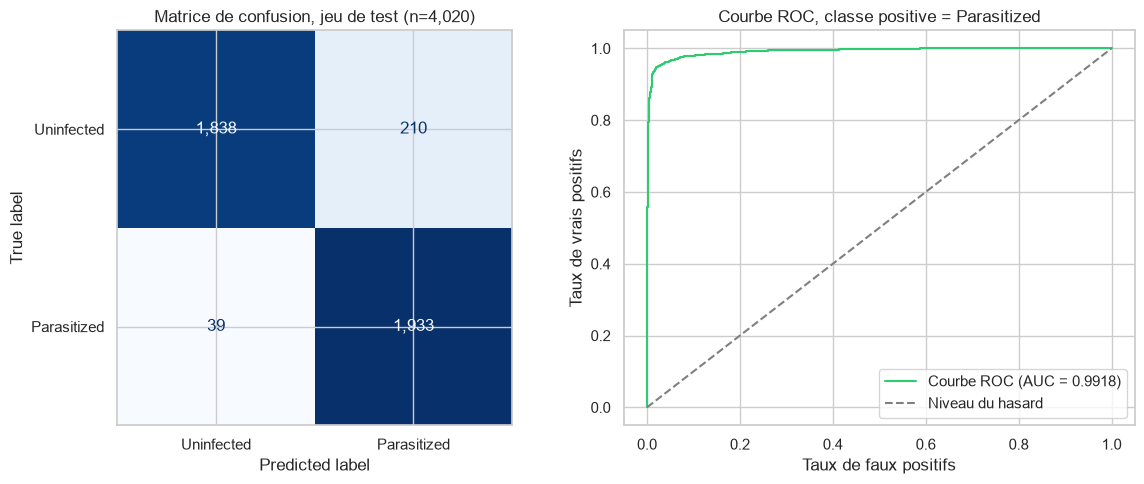

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Uninfected", "Parasitized"]).plot(
    ax=axes[0], cmap="Blues", colorbar=False, values_format=",d"
)
axes[0].set_title(f"Matrice de confusion, jeu de test (n={len(y_true):,})")

fpr, tpr, _ = roc_curve(y_true, y_prob)
axes[1].plot(fpr, tpr, label=f"Courbe ROC (AUC = {roc_auc:.4f})", color="#2ecc71")
axes[1].plot([0, 1], [0, 1], linestyle="--", color="gray", label="Niveau du hasard")
axes[1].set_xlabel("Taux de faux positifs")
axes[1].set_ylabel("Taux de vrais positifs")
axes[1].set_title("Courbe ROC, classe positive = Parasitized")
axes[1].legend(loc="lower right")

plt.tight_layout()
plt.show()

> **Lecture.** La matrice confirme que les erreurs sont peu nombreuses dans les deux classes, avec ici davantage de faux positifs (210) que de faux négatifs (39), conséquence voulue d'un seuil favorisant la sensibilité. La courbe ROC élevée montre une bonne capacité de classement ; le seuil a été gelé sur la validation et n'a pas été ajusté sur le test, mais il devra être revalidé selon le coût clinique de chaque type d'erreur.


## 4. Sensibilité à la prévalence : à quoi ressembleraient VPP/VPN hors de ce dataset équilibré

Le jeu de test ci-dessus est artificiellement équilibré ~50/50 (une propriété du design original du dataset NIH), ce qui est très éloigné de la prévalence réelle d'un dépistage de terrain. La VPP et la VPN dépendent toutes deux de la prévalence, pas seulement de la sensibilité/spécificité, donc les valeurs de VPP/VPN mesurées ci-dessus ne sont valables que pour une population infectée à ~50% ; elles ne se transposent pas directement à un contexte de dépistage. En utilisant la sensibilité et la spécificité mesurées (qui, contrairement à la VPP/VPN, sont indépendantes de la prévalence) et la règle de Bayes, la cellule ci-dessous recalcule à quoi ressembleraient la VPP/VPN sous une hypothèse illustrative de faible prévalence, pour rendre cela concret plutôt que de l'affirmer dans l'abstrait.

In [7]:
prevalence_scenarios = [0.50, 0.10, 0.02]  # 0.50 correspond a ce jeu de test ; 0.10 et 0.02 sont des hypotheses illustratives de niveau depistage, pas des valeurs mesurees
rows = []
for prev in prevalence_scenarios:
    ppv_p, npv_p = ppv_npv_at_prevalence(sensitivity, specificity, prev)
    rows.append({"assumed_prevalence": prev, "PPV": round(ppv_p, 4), "NPV": round(npv_p, 4)})

prevalence_table = pd.DataFrame(rows)
display(prevalence_table)

,assumed_prevalence,PPV,NPV
0,0.50,0.9053,0.9784
1,0.10,0.5151,0.9976
2,0.02,0.1632,0.9996


> **Décision d'usage.** À 2 % de prévalence supposée, la VPP estimée tombe à **16,32 %** (51,5 % à 10 %) tandis que la VPN atteint **99,96 %**. Le système est donc plus crédible comme outil de tri ou d'exclusion assistée que comme confirmation diagnostique autonome ; tout résultat positif doit rester confirmé par un professionnel.


À sensibilité et spécificité fixées aux valeurs mesurées sur le jeu de test, la VPP chute nettement quand la prévalence supposée passe de 50 % à 2 %. C'est un comportement bayésien attendu, pas un défaut du modèle.

La conséquence est opérationnelle : en dépistage à faible prévalence, une prédiction positive demanderait une deuxième lecture de confirmation bien plus souvent que ne le laisse penser la VPP brute mesurée ici. C'est ce type d'écart entre performance sur benchmark et performance opérationnelle qu'une évaluation de la valeur médicale et opérationnelle doit rendre explicite.

## 5. Interprétabilité : cartes de saillance par gradient

Pour voir à quoi le modèle réagit, une carte de saillance par gradient simple (Simonyan et al., 2013) est calculée sur quelques images de test. On prend le gradient du score de la classe prédite par rapport à chaque pixel d'entrée. Cela met en évidence les pixels qui changeraient le plus la confiance du modèle s'ils étaient perturbés. L'implémentation utilise directement `torch.autograd`, sans bibliothèque d'interprétabilité externe. Elle fonctionne quelle que soit l'architecture retenue par le notebook 03, ce qui compte ici : ce choix n'est connu qu'une fois le notebook 03 exécuté.

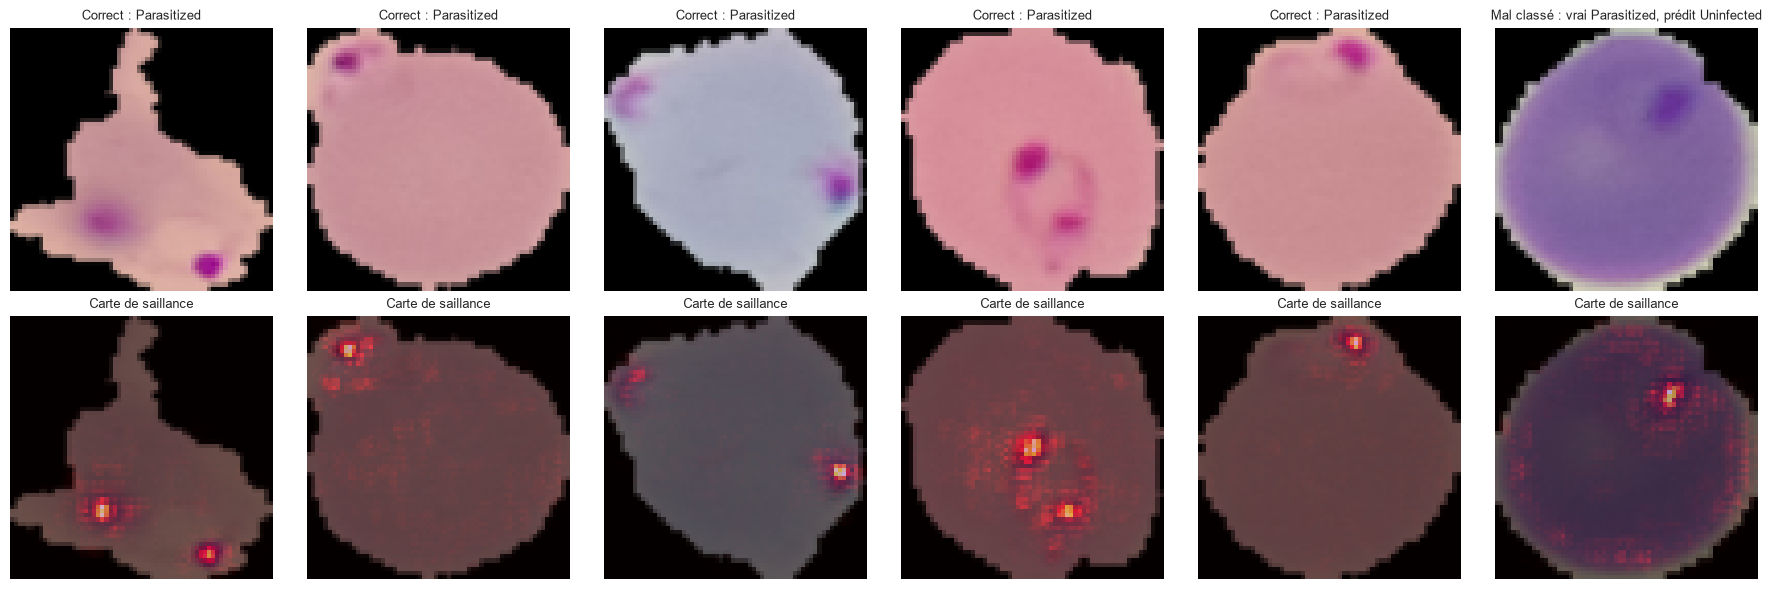

In [8]:
# Quelques exemples Parasitized correctement classes, plus une erreur de classification si le jeu de test en contient une.
correct_parasitized_idx = np.where((y_true == POS_IDX) & (y_pred == POS_IDX))[0]
misclassified_idx = np.where(y_true != y_pred)[0]

rng = np.random.default_rng(42)
example_idx = list(rng.choice(correct_parasitized_idx, size=min(5, len(correct_parasitized_idx)), replace=False))
example_titles = ["Correct : Parasitized"] * len(example_idx)
if len(misclassified_idx) > 0:
    mis_i = int(rng.choice(misclassified_idx, size=1)[0])
    example_idx.append(mis_i)
    true_lbl = IDX_TO_LABEL[y_true[mis_i]]
    pred_lbl = IDX_TO_LABEL[y_pred[mis_i]]
    example_titles.append(f"Mal classé : vrai {true_lbl}, prédit {pred_lbl}")

n = len(example_idx)
fig, axes = plt.subplots(2, n, figsize=(3 * n, 6))
for col, (idx, title) in enumerate(zip(example_idx, example_titles)):
    img_tensor, label = test_dataset[idx]
    target_class = int(y_pred[idx])  # explique la prediction du modele lui-meme
    saliency = compute_saliency(model, img_tensor, target_class, DEVICE)

    img_np = denormalize(img_tensor, IMAGENET_MEAN, IMAGENET_STD).permute(1, 2, 0).numpy()
    axes[0, col].imshow(img_np)
    axes[0, col].set_title(title, fontsize=9)
    axes[0, col].axis("off")

    axes[1, col].imshow(img_np)
    axes[1, col].imshow(saliency, cmap="hot", alpha=0.55)
    axes[1, col].set_title("Carte de saillance", fontsize=9)
    axes[1, col].axis("off")

plt.tight_layout()
plt.show()

> **Observation d'interprétabilité.** Les cartes fournissent un contrôle qualitatif de l'attention du modèle, mais ne constituent pas une preuve causale. Avant un usage clinique, leur lecture doit être revue par des spécialistes sur un échantillon plus large, avec recherche systématique d'attention portée aux bords ou au fond plutôt qu'au corps cellulaire.


Les cartes de saillance se lisent directement. Ce qui compte est l'endroit où se concentre la zone chaude : à l'intérieur du corps cellulaire, ou bien sur les bords et dans le fond.

Dans le premier cas, le modèle regarde des zones de coloration du parasite plausibles. Dans le second, il s'appuie sur des artefacts, contour de la cellule ou texture du fond.

## 6. Discussion : valeur médicale et opérationnelle, limites, recommandations

### Valeur médicale et opérationnelle potentielle

Les résultats mesurés ci-dessus (Section 3) montrent un modèle capable de distinguer des cellules parasitées et saines sur ce jeu de test avec un niveau de performance élevé pour une tâche d'imagerie microscopique. Dans un contexte clinique réel, un tel outil ne devrait jamais fonctionner comme un diagnostic autonome. Sa valeur se situe plutôt dans deux usages concrets :

* **Aide au tri (pre-screening) :** faire remonter en priorité les lames ou zones suspectes pour lecture par un technicien, utile dans des contextes de forte charge d'échantillons ou de personnel qualifié limité.
* **Second lecteur :** apporter un avis indépendant en complément de la lecture humaine, pour réduire le risque d'erreur d'attention sur de longues séries de lames, sans remplacer la décision du biologiste.

La sensibilité mesurée (Section 3) est la métrique la plus critique cliniquement : rater une infection réelle (faux négatif) a des conséquences plus graves qu'un faux positif, qui se traduit seulement par une vérification supplémentaire. La section 4 montre cependant qu'à une prévalence réaliste de terrain, bien plus faible que les 50% de ce jeu de données, la valeur prédictive positive chute nettement : un résultat positif du modèle nécessiterait donc une confirmation systématique avant toute décision clinique.

### Limites réelles de cette évaluation

* **Un seul type de microscope et de coloration :** toutes les images proviennent du même protocole (frottis mince, même centre hospitalier, même numérisation). Rien ne garantit une performance équivalente sur des lames d'un autre laboratoire, d'un autre scanner ou d'une autre coloration.
* **Aucune validation externe :** le test interne est groupé par patient, mais provient du même hôpital, microscope et protocole de coloration que l'entraînement. Une généralisation à un autre centre n'est donc pas démontrée.
* **Prévalences hypothétiques :** les scénarios à 10 % et 2 % sont illustratifs. Ils supposent que sensibilité et spécificité restent identiques dans une autre population, hypothèse qui doit être vérifiée par validation externe.
* **Deux niveaux d'analyse :** les métriques principales sont calculées par cellule. L'analyse patient applique séparément une règle explicite — seuil cellule et nombre minimal de cellules suspectes, tous deux gelés sur la validation — mais elle reste exploratoire et ne remplace pas une évaluation au niveau lame. Réglée sur 30 patients de validation où elle atteignait 100 % de sensibilité et de spécificité (au moins 6 cellules suspectes), elle ne généralise pas au test : 20 des 22 patients infectés sont détectés (sensibilité 90,9 %, spécificité 100 %), sous la cible de 98 %. Plusieurs patients infectés n'ont que quelques cellules parasitées, ce qui rend le comptage fragile.
* **Petit test patient :** aucun patient du test n'a été vu à l'entraînement, mais le test ne compte que 30 patients. Les intervalles bootstrap restent donc à interpréter avec prudence.
* **Marquage réglementaire :** un usage clinique réel nécessiterait un marquage CE-IVD (dispositif médical de diagnostic in vitro), avec toute la documentation, les essais cliniques et le suivi post-marché associés. Ce notebook est un travail de faisabilité technique, pas un dispositif validé.

### Recommandations concrètes pour la suite

1. Constituer ou obtenir un second jeu de données, idéalement d'un autre centre/microscope, pour une validation externe avant toute conclusion sur la généralisation.
2. Compléter l'IC bootstrap par patient (déjà calculé ci-dessus) par une validation croisée groupée par patient, le test ne comptant que 30 patients ; y régler aussi la règle d'agrégation patient, trop fragile sur 30 patients de validation.
3. Étudier la performance sous des scénarios de prévalence réalistes (au lieu du calcul illustratif de la Section 4), en construisant un jeu de test délibérément déséquilibré.
4. Revalider avec les biologistes le seuil et la règle d'agrégation gelés sur la validation interne avant toute étude externe ou utilisation sur des lames complètes.
5. Si le projet avance vers un usage clinique, engager le processus de qualification réglementaire (CE-IVD) en parallèle du développement technique, pas après.

## Conclusion générale et décisions de suite

La chaîne complète transforme **27 558 images auditées** en splits étanches au niveau patient, compare deux stratégies de modélisation et évalue le SimpleCNN retenu sur **4 020 images de test**. Au seuil gelé sur la validation, le modèle atteint 93,81 % d'accuracy, 98,02 % de sensibilité, 89,75 % de spécificité et 0,9918 de ROC-AUC ; la règle patient exploratoire n'atteint que 90,9 % de sensibilité au test. Ces résultats démontrent une faisabilité technique sur le benchmark NIH, mais pas une validité clinique externe.

Les décisions pour la prochaine itération sont les suivantes :

1. conserver le modèle comme outil expérimental de **pré-tri ou second lecteur**, jamais comme diagnostic autonome ;
2. utiliser le seuil cellule et la règle patient gelés sur la validation interne, puis les confirmer avec des biologistes selon l'usage réel ;
3. compléter l'IC bootstrap par une validation croisée groupée par patient et conduire une validation externe multi-centrique ;
4. évaluer une prévalence et des conditions d'acquisition représentatives du terrain ;
5. auditer l'explicabilité sur davantage d'images et comparer des méthodes plus robustes comme Grad-CAM ;
6. ne considérer un déploiement qu'après validation clinique et cadrage réglementaire CE-IVD.
